In [1]:
#%pip install stable-baselines3[extra] pettingzoo gymnasium[mujoco] imageio imageio-ffmpeg matplotlib

In [2]:
# ══════════════════════════════════════════════
#   CONFIGURATION — edit here and re-run
# ══════════════════════════════════════════════
CFG = {
    "total_timesteps": 100_000,   # ← change to 500_000 or 2_000_000 for serious training
    "race_duration_s": 60,        # maximum race duration in seconds
    "finish_line_x":  100.0,      # finish line position in metres
    "timestep_sim":   0.01,       # MuJoCo physics timestep
    "video_fps":      30,
    "save_dir":       "olympic_output",
    "seed":           42,
}

import os
os.makedirs(CFG["save_dir"], exist_ok=True)
print("✅ Configuration loaded")
print(f"   Training timesteps : {CFG['total_timesteps']:,}")
print(f"   Finish line        : x = {CFG['finish_line_x']} m")
print(f"   Race time limit    : {CFG['race_duration_s']} s")

✅ Configuration loaded
   Training timesteps : 100,000
   Finish line        : x = 100.0 m
   Race time limit    : 60 s


In [3]:
import os, xml.etree.ElementTree as ET
import gymnasium.envs.mujoco as mujoco_envs

BASE_PATH  = os.path.dirname(mujoco_envs.__file__)
ASSETS_DIR = os.path.join(BASE_PATH, "assets")

NAME_ATTRS = ["name","joint","geom","body","mesh","texture","material",
              "site","tendon","class","childclass","actuator",
              "target","cranksite","slidersite"]

def parse_agent(xml_path, prefix, spawn_pos):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    def prefixify(elem):
        for attr in NAME_ATTRS:
            if attr in elem.attrib and not elem.attrib[attr].startswith(prefix+"/"):
                elem.attrib[attr] = f"{prefix}/{elem.attrib[attr]}"
        for child in elem:
            prefixify(child)
    prefixify(root)

    # Cuerpos: primer body del worldbody, reposicionado
    bodies = []
    wb = root.find("worldbody")
    if wb is not None:
        for body in list(wb):
            for geom in list(body.findall(".//geom")):
                if geom.get("type") == "plane":
                    for p in body.iter():
                        if geom in list(p):
                            p.remove(geom); break
            body.attrib["pos"] = spawn_pos
            bodies.append(body)

    # Actuadores
    actuators = [e for e in (root.find("actuator") or []) ]

    # Assets con rutas absolutas
    assets = []
    for elem in list(root.find("asset") or []):
        if "file" in elem.attrib:
            fname = elem.attrib["file"]
            if not os.path.isabs(fname):
                full = os.path.join(ASSETS_DIR, fname)
                if os.path.exists(full):
                    elem.attrib["file"] = full
        assets.append(elem)

    # Default envuelto en clase propia
    default_wrapper = None
    def_sec = root.find("default")
    if def_sec is not None:
        default_wrapper = ET.Element("default", attrib={"class": prefix})
        for child in list(def_sec):
            default_wrapper.append(child)

    contacts   = list(root.find("contact")  or [])
    equalities = list(root.find("equality") or [])
    tendons    = list(root.find("tendon")   or [])

    return bodies, actuators, assets, default_wrapper, contacts, equalities, tendons

agents_cfg = [
    ("ant",      os.path.join(ASSETS_DIR, "ant.xml"),          "0  4    0.75"),
    ("cheetah",  os.path.join(ASSETS_DIR, "half_cheetah.xml"), "0  0    0.5"),
    ("humanoid", os.path.join(ASSETS_DIR, "humanoid.xml"),     "0 -4    1.25"),
]
parsed = {name: parse_agent(path, name, pos) for name, path, pos in agents_cfg}

# ── Construir XML maestro
root_elem = ET.Element("mujoco", attrib={"model": "ai_olympics"})
ET.SubElement(root_elem, "compiler", attrib={"angle":"degree","inertiafromgeom":"true","coordinate":"local"})
ET.SubElement(root_elem, "option",   attrib={"timestep":str(CFG["timestep_sim"]),"integrator":"RK4","gravity":"0 0 -9.81"})

asset_elem = ET.SubElement(root_elem, "asset")
for name,_,__ in agents_cfg:
    for a in parsed[name][2]: asset_elem.append(a)

default_root = ET.SubElement(root_elem, "default")
for name,_,__ in agents_cfg:
    w = parsed[name][3]
    if w is not None: default_root.append(w)

wb_elem = ET.SubElement(root_elem, "worldbody")
ET.SubElement(wb_elem, "light", attrib={"directional":"true","diffuse":".8 .8 .8","specular":".2 .2 .2","pos":"50 0 10","dir":"0 0 -1"})
ET.SubElement(wb_elem, "geom",  attrib={"name":"main_floor","type":"plane","pos":"50 0 0","size":"60 12 0.1","rgba":"0.15 0.25 0.35 1","condim":"3"})
# Líneas de carril y meta
for y,rgba in [("4","1 0.85 0 0.5"),("0","0 0.85 1 0.5"),("-4","1 0.4 0.4 0.5")]:
    ET.SubElement(wb_elem,"geom",attrib={"type":"box","pos":"50 "+y+" 0.015","size":"55 0.05 0.005","rgba":rgba,"contype":"0","conaffinity":"0"})
# Línea de meta (visible)
ET.SubElement(wb_elem,"geom",attrib={"type":"box","pos":f"{CFG['finish_line_x']} 0 1","size":"0.1 12 1","rgba":"1 1 0 0.3","contype":"0","conaffinity":"0"})

for name,_,__ in agents_cfg:
    for body in parsed[name][0]: wb_elem.append(body)

for tag, idx in [("contact",4),("equality",5),("tendon",6)]:
    sec = ET.SubElement(root_elem, tag)
    for name,_,__ in agents_cfg:
        for e in parsed[name][idx]: sec.append(e)

act_elem = ET.SubElement(root_elem, "actuator")
for name,_,__ in agents_cfg:
    for a in parsed[name][1]: act_elem.append(a)

tree = ET.ElementTree(root_elem)
ET.indent(tree, space="  ")
tree.write("arena.xml", encoding="unicode", xml_declaration=False)

import mujoco
try:
    m = mujoco.MjModel.from_xml_path("arena.xml")
    print(f"✅ arena.xml OK — nq={m.nq}  nv={m.nv}  nu={m.nu}  nbody={m.nbody}")
except Exception as e:
    print(f"❌ {e}")

✅ arena.xml OK — nq=48  nv=46  nu=31  nbody=34


C:\Users\Carla\AppData\Local\Temp\ipykernel_17000\1757104025.py:37: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)' or 'elem is not None' test instead.
  actuators = [e for e in (root.find("actuator") or []) ]
C:\Users\Carla\AppData\Local\Temp\ipykernel_17000\1757104025.py:41: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)' or 'elem is not None' test instead.
  for elem in list(root.find("asset") or []):
C:\Users\Carla\AppData\Local\Temp\ipykernel_17000\1757104025.py:60: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)' or 'elem is not None' test instead.
  tendons    = list(root.find("tendon")   or [])


In [4]:
import numpy as np
import gymnasium as gym
import mujoco

class SingleAgentRaceEnv(gym.Env):
    """
    gym.Env wrapper to train a single agent in its own MuJoCo model
    (standard Gymnasium ant / half_cheetah / humanoid environments).
    Reward = forward progress in X minus a small control penalty.
    """
    metadata = {"render_modes": ["rgb_array"]}

    # Only these agents support the terminate_when_unhealthy parameter
    _HEALTHY_AGENTS = {"ant", "humanoid"}

    _ENV_IDS = {
        "ant":      "Ant-v5",
        "cheetah":  "HalfCheetah-v5",
        "humanoid": "Humanoid-v5",
    }

    def __init__(self, agent_name: str, finish_x: float = 100.0,
                 max_steps: int = 2000, render_mode=None):
        super().__init__()
        self.agent_name  = agent_name
        self.finish_x    = finish_x
        self.max_steps   = max_steps
        self._step_count = 0
        self.render_mode = render_mode

        # Only pass terminate_when_unhealthy to agents that support it
        extra_kwargs = {}
        if agent_name in self._HEALTHY_AGENTS:
            extra_kwargs["terminate_when_unhealthy"] = True

        # Use the official Gymnasium environment (independent physics)
        self._env = gym.make(
            self._ENV_IDS[agent_name],
            render_mode=render_mode,
            **extra_kwargs,
        )
        self.observation_space = self._env.observation_space
        self.action_space      = self._env.action_space

    def reset(self, seed=None, options=None):
        self._step_count = 0
        obs, info = self._env.reset(seed=seed)
        self._prev_x = self._get_x()
        return obs, info

    def _get_x(self):
        return float(self._env.unwrapped.data.qpos[0])

    def step(self, action):
        obs, base_reward, terminated, truncated, info = self._env.step(action)
        self._step_count += 1

        x_now = self._get_x()
        # Reward: scaled forward progress + finish-line bonus
        dx     = x_now - self._prev_x
        reward = dx * 10.0
        self._prev_x = x_now

        if x_now >= self.finish_x:
            reward    += 500.0      # finish-line bonus
            terminated = True

        if self._step_count >= self.max_steps:
            truncated = True

        info["x_position"] = x_now
        return obs, reward, terminated, truncated, info

    def render(self):
        return self._env.render()

    def close(self):
        self._env.close()

print("✅ SingleAgentRaceEnv defined")

✅ SingleAgentRaceEnv defined


In [ ]:
from stable_baselines3 import PPO, SAC, DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
import numpy as np, os, time

class RaceMetricsCallback(BaseCallback):
    """Records per-episode reward and final X position for plotting."""
    def __init__(self, agent_name):
        super().__init__()
        self.agent_name = agent_name
        self.ep_rewards = []
        self.ep_x_final = []
        self._ep_reward = 0.0

    def _on_step(self):
        self._ep_reward += float(self.locals["rewards"][0])
        info = self.locals["infos"][0]
        if self.locals["dones"][0]:
            self.ep_rewards.append(self._ep_reward)
            self.ep_x_final.append(info.get("x_position", 0.0))
            self._ep_reward = 0.0
        return True


def train_agent(agent_name, total_timesteps, save_dir, seed=42):
    print(f"\n{'─'*50}")
    print(f"  Training {agent_name.upper()} · {total_timesteps:,} steps")
    print(f"{'─'*50}")

    env = Monitor(SingleAgentRaceEnv(agent_name, finish_x=CFG["finish_line_x"]))
    cb  = RaceMetricsCallback(agent_name)

    if agent_name == "ant":
        model = PPO("MlpPolicy", env, verbose=0, seed=seed,
                    learning_rate=3e-4, n_steps=2048, batch_size=64,
                    n_epochs=10, gamma=0.99, gae_lambda=0.95,
                    clip_range=0.2, ent_coef=0.01)

    elif agent_name == "cheetah":
        from gymnasium.spaces import Discrete
        from gymnasium import ActionWrapper

        class DiscretizeCheetah(ActionWrapper):
            """Maps 9 discrete actions to fixed combinations of continuous actuators."""
            ACTIONS = [
                np.zeros(6),
                np.array([ 1, 0, 0, 0, 0, 0], dtype=np.float32),
                np.array([-1, 0, 0, 0, 0, 0], dtype=np.float32),
                np.array([ 1, 1, 0, 0, 0, 0], dtype=np.float32),
                np.array([ 0, 0, 1, 1, 0, 0], dtype=np.float32),
                np.array([ 0, 0, 0, 0, 1, 1], dtype=np.float32),
                np.array([ 1, 0, 1, 0, 1, 0], dtype=np.float32),
                np.array([ 0, 1, 0, 1, 0, 1], dtype=np.float32),
                np.ones(6,  dtype=np.float32),
            ]
            def __init__(self, env):
                super().__init__(env)
                self.action_space = Discrete(len(self.ACTIONS))
            def action(self, act):
                return self.ACTIONS[act]

        base_env = SingleAgentRaceEnv("cheetah", finish_x=CFG["finish_line_x"])
        env = Monitor(DiscretizeCheetah(base_env))
        cb  = RaceMetricsCallback("cheetah")
        model = DQN("MlpPolicy", env, verbose=0, seed=seed,
                    learning_rate=1e-4, buffer_size=50_000,
                    learning_starts=1000, batch_size=64,
                    gamma=0.99, exploration_fraction=0.2,
                    exploration_final_eps=0.05,
                    target_update_interval=500)

    elif agent_name == "humanoid":
        model = SAC("MlpPolicy", env, verbose=0, seed=seed,
                    learning_rate=3e-4, buffer_size=300_000,
                    learning_starts=5000, batch_size=256,
                    gamma=0.99, tau=0.005,
                    ent_coef="auto", target_update_interval=1)

    t0 = time.time()
    model.learn(total_timesteps=total_timesteps, callback=cb, progress_bar=True)
    elapsed = time.time() - t0

    path = os.path.join(save_dir, f"{agent_name}_model")
    model.save(path)
    print(f"  ✅ Saved to {path}.zip  ({elapsed:.0f}s)")
    env.close()
    return model, cb


# ── Train all three agents
models, callbacks = {}, {}
for ag in ["ant", "cheetah", "humanoid"]:
    models[ag], callbacks[ag] = train_agent(
        ag, CFG["total_timesteps"], CFG["save_dir"], CFG["seed"]
    )

print("\n🎓 Training complete for all three agents.")

c:\Users\Carla\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Carla\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Carla\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framewo


──────────────────────────────────────────────────
  Training ANT · 100,000 steps
──────────────────────────────────────────────────


Output()

Output()

  ✅ Saved to olympic_output\ant_model.zip  (98s)

──────────────────────────────────────────────────
  Training CHEETAH · 100,000 steps
──────────────────────────────────────────────────


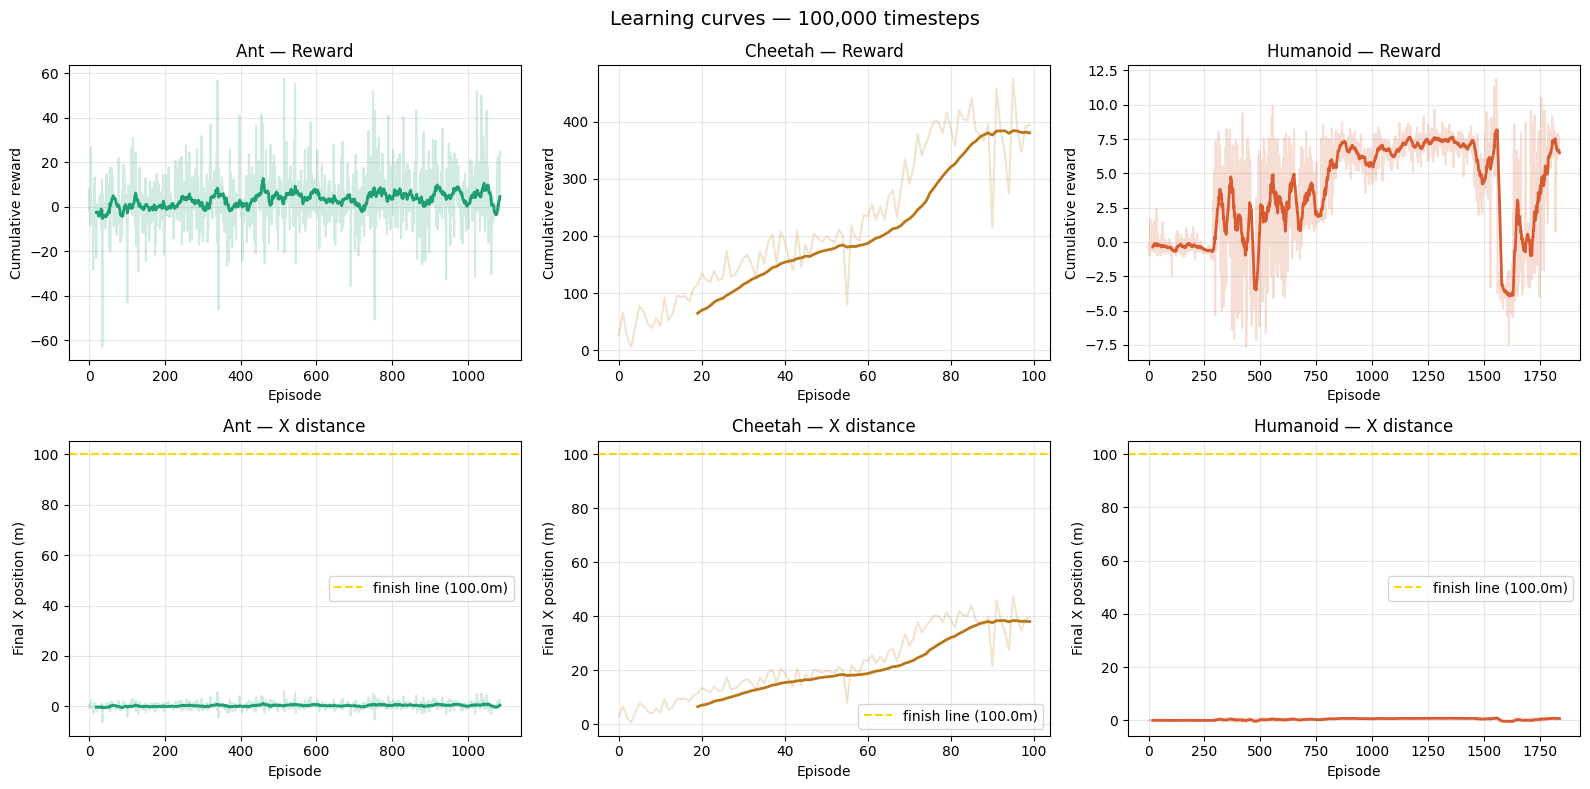

✅ Learning curves saved to olympic_output\learning_curves.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np, os

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f"Learning curves — {CFG['total_timesteps']:,} timesteps", fontsize=14)

colors = {"ant": "#1D9E75", "cheetah": "#BA7517", "humanoid": "#D85A30"}

for col, ag in enumerate(["ant", "cheetah", "humanoid"]):
    cb = callbacks[ag]
    c  = colors[ag]

    def smooth(x, w=20):
        if len(x) < w: return x
        return np.convolve(x, np.ones(w)/w, mode="valid")

    # Cumulative reward per episode
    ax = axes[0, col]
    raw = np.array(cb.ep_rewards)
    ax.plot(raw, alpha=0.2, color=c)
    if len(raw) >= 20:
        ax.plot(range(19, len(raw)), smooth(raw), color=c, linewidth=2)
    ax.set_title(f"{ag.capitalize()} — Reward")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Cumulative reward")
    ax.grid(alpha=0.3)

    # Final X position per episode
    ax2 = axes[1, col]
    xf = np.array(cb.ep_x_final)
    ax2.plot(xf, alpha=0.2, color=c)
    if len(xf) >= 20:
        ax2.plot(range(19, len(xf)), smooth(xf), color=c, linewidth=2)
    ax2.axhline(CFG["finish_line_x"], color="gold", linestyle="--",
                linewidth=1.5, label=f"finish line ({CFG['finish_line_x']}m)")
    ax2.set_title(f"{ag.capitalize()} — X distance")
    ax2.set_xlabel("Episode")
    ax2.set_ylabel("Final X position (m)")
    ax2.legend()
    ax2.grid(alpha=0.3)

plt.tight_layout()
path_plot = os.path.join(CFG["save_dir"], "learning_curves.png")
plt.savefig(path_plot, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Learning curves saved to {path_plot}")

In [ ]:
import mujoco, time, imageio, numpy as np
from pettingzoo import ParallelEnv
import functools, gymnasium as gym, matplotlib.pyplot as plt, os

class OlympicRaceEnv(ParallelEnv):
    """Multi-agent race environment built on PettingZoo ParallelEnv."""
    metadata = {"render_modes": ["rgb_array"], "name": "olympic_race_v0"}

    def __init__(self, finish_x=100.0, race_duration_s=60.0, timestep=0.01):
        self.finish_x  = finish_x
        self.max_steps = int(race_duration_s / timestep)
        self.model     = mujoco.MjModel.from_xml_path("arena.xml")
        self.data      = mujoco.MjData(self.model)
        self.renderer  = mujoco.Renderer(self.model, height=480, width=640)

        self.possible_agents = ["ant", "cheetah", "humanoid"]
        self.agents = self.possible_agents[:]

        nu = self.model.nu
        self._ctrl_slices = {
            "ant":      slice(0, 8),
            "cheetah":  slice(8, 14),
            "humanoid": slice(14, nu),
        }
        self._act_sizes = {"ant": 8, "cheetah": 6, "humanoid": nu - 14}

        # qpos X index for each agent
        self._x_idx = {}
        for ag, jname in [("ant","ant/root"),("cheetah","cheetah/rootx"),("humanoid","humanoid/root")]:
            try:
                jid = mujoco.mj_name2id(self.model, mujoco.mjtObj.mjOBJ_JOINT, jname)
                self._x_idx[ag] = int(self.model.jnt_qposadr[jid])
            except:
                self._x_idx[ag] = 0

        self._step_count = 0
        self._finished   = {}  # agent → step when it crossed the finish line
        self._finish_x_at= {}  # agent → X at finish

    @functools.lru_cache(maxsize=None)
    def observation_space(self, agent):
        sizes = {"ant": 27, "cheetah": 17, "humanoid": 376}
        return gym.spaces.Box(-np.inf, np.inf, (sizes[agent],), dtype=np.float64)

    @functools.lru_cache(maxsize=None)
    def action_space(self, agent):
        return gym.spaces.Box(-1.0, 1.0, (self._act_sizes[agent],), dtype=np.float32)

    def _get_obs(self, agent):
        size = self.observation_space(agent).shape[0]
        full = np.concatenate([self.data.qpos, self.data.qvel])
        return (full[:size] if len(full) >= size
                else np.pad(full, (0, size - len(full)))).astype(np.float64)

    def _get_x(self, agent):
        return float(self.data.qpos[self._x_idx[agent]])

    def reset(self, seed=None, options=None):
        mujoco.mj_resetData(self.model, self.data)
        self.agents      = self.possible_agents[:]
        self._step_count = 0
        self._finished   = {}
        self._finish_x_at= {}
        self._prev_x = {ag: self._get_x(ag) for ag in self.agents}
        return {ag: self._get_obs(ag) for ag in self.agents}, {}

    def step(self, actions):
        for ag, act in actions.items():
            self.data.ctrl[self._ctrl_slices[ag]] = np.clip(act, -1.0, 1.0)
        mujoco.mj_step(self.model, self.data)
        self._step_count += 1

        observations, rewards, terminations, truncations = {}, {}, {}, {}
        time_up = self._step_count >= self.max_steps

        for ag in list(self.agents):
            x = self._get_x(ag)
            observations[ag] = self._get_obs(ag)
            rewards[ag]      = float(x - self._prev_x[ag]) * 10.0
            self._prev_x[ag] = x

            finished = x >= self.finish_x
            if finished and ag not in self._finished:
                self._finished[ag]    = self._step_count
                self._finish_x_at[ag] = x
                rewards[ag] += 500.0

            terminations[ag] = finished
            truncations[ag]  = time_up and not finished

        self.agents = [ag for ag in self.agents
                       if not terminations[ag] and not truncations[ag]]

        return observations, rewards, terminations, truncations, {ag: {} for ag in observations}

    def render(self):
        self.renderer.update_scene(self.data)
        return self.renderer.render()

    def close(self):
        self.renderer.close()


def run_race_and_record(models_dict, env: OlympicRaceEnv,
                        save_dir: str, fps: int = 30):
    """Run the final race, record a video, print the ranking."""
    obs, _ = env.reset()
    frames  = []
    step    = 0
    all_x   = {ag: [0.0] for ag in env.possible_agents}

    print("🏁 Race started!")
    while env.agents:
        actions = {}
        for ag in env.agents:
            action, _ = models_dict[ag].predict(obs[ag], deterministic=True)
            actions[ag] = action

        obs, rewards, terminations, truncations, _ = env.step(actions)
        step += 1

        for ag in env.possible_agents:
            all_x[ag].append(env._get_x(ag))

        # Capture frame every 3 physics steps (~30 fps video)
        if step % 3 == 0:
            frames.append(env.render())

        if step % 500 == 0:
            pos_str = " | ".join(
                f"{ag}: {env._get_x(ag):.1f}m" for ag in env.possible_agents
            )
            print(f"  t={step * env.model.opt.timestep:.1f}s  {pos_str}")

    print("🏁 Race finished.")

    # ── Video
    video_path = os.path.join(save_dir, "final_race.mp4")
    imageio.mimwrite(video_path, frames, fps=fps, macro_block_size=None)
    print(f"📹 Video saved: {video_path}")

    # ── Ranking
    ranking = []
    for ag in env.possible_agents:
        if ag in env._finished:
            t_finish = env._finished[ag] * env.model.opt.timestep
            ranking.append((ag, t_finish, env._finish_x_at[ag], "✅ finished"))
        else:
            ranking.append((ag, None, env._get_x(ag), "⏱ time limit"))

    ranking.sort(key=lambda r: (r[1] is None, r[1] if r[1] else -r[2]))

    print("\n" + "═"*52)
    print("  🏆  FINAL RANKING")
    print("═"*52)
    rank_lines = []
    for pos, (ag, t, x, status) in enumerate(ranking, 1):
        t_str = f"{t:.2f}s" if t else "—"
        line  = f"  {pos}. {ag.capitalize():12s} | {x:6.1f}m | {t_str:>8} | {status}"
        print(line)
        rank_lines.append(line)
    print("═"*52)

    rank_path = os.path.join(save_dir, "ranking.txt")
    with open(rank_path, "w") as f:
        f.write("FINAL RACE RANKING\n" + "═"*52 + "\n")
        for line in rank_lines:
            f.write(line + "\n")
    print(f"📄 Ranking saved: {rank_path}")

    # ── Race progress chart
    fig, ax = plt.subplots(figsize=(12, 5))
    colors  = {"ant": "#1D9E75", "cheetah": "#BA7517", "humanoid": "#D85A30"}
    for ag in env.possible_agents:
        ts = [i * env.model.opt.timestep for i in range(len(all_x[ag]))]
        ax.plot(ts, all_x[ag], label=ag.capitalize(), color=colors[ag], linewidth=2)
    ax.axhline(env.finish_x, color="gold", linestyle="--",
               linewidth=1.5, label=f"Finish line ({env.finish_x}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("X position (m)")
    ax.set_title("Final race — agent positions over time")
    ax.legend()
    ax.grid(alpha=0.3)
    race_plot = os.path.join(save_dir, "race_positions.png")
    plt.savefig(race_plot, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"📊 Race chart saved: {race_plot}")

    return ranking


# ── RUN
race_env = OlympicRaceEnv(
    finish_x=CFG["finish_line_x"],
    race_duration_s=CFG["race_duration_s"],
    timestep=CFG["timestep_sim"],
)

ranking = run_race_and_record(models, race_env, CFG["save_dir"], fps=CFG["video_fps"])
race_env.close()

ValueError: Image width 854 > framebuffer width 640. Either reduce the image
width or specify a larger offscreen framebuffer in the model XML using the
clause:
<visual>
  <global offwidth="my_width"/>
</visual>